<a href="https://colab.research.google.com/github/yuhui-0611/ESAA/blob/main/ESAA_OB_WEEK09_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5.2 합성곱 신경망 맛보기

< fashion_mnist dataset >

- torchvision에 내장된 예제 데이터
- 운동화, 셔츠, 샌들 같은 작은 이미지의 모음
- 기본 MNIST 데이터셋처럼 열가지로 분류될 수 있는 28x28 픽셀의 이미지 7만 개로 구성
- train : numpy 배열
- test : 정수 값을 갖는 배열



```
0 : T-Shirt
1 : Trouser
2 : Pullover
3 : Dress
4 : Coat
5 : Sandal
6 : Shirt
7 : Sneaker
8 : Bag
9 : Ankle Boot
```



In [1]:
# 5-1 라이브러리 호출
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms # 데이터 전처리를 위해 사용하는 라이브러리
from torch.utils.data import Dataset, DataLoader

In [2]:
# 5-2 CPU 혹은 GPU 장치 확인
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

< GPU 사용 설명 >

- 일반적으로 하나의 GPU를 사용할 때 사용하는 코드

```
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = Net()
model.to(device)
```

- 여러 개의 GPU를 사용할 경우 다음과 같이 nn.DataParallel을 사용

```
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net()
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(net)
model.to(device)
```

- nn.DataParallel 사용 시 batch size가 자동으로 각 GPU에 분배되는 구조임
- 따라서 GPU 개수에 맞게 batch size를 늘려줘야 함

In [3]:
# 5-3 fashion_mnist 데이터셋 내려받기
train_dataset = torchvision.datasets.FashionMNIST('/content/drive/MyDrive/ESAA', download=True, transform=transforms.Compose([transforms.ToTensor()]))
test_dataset = torchvision.datasets.FashionMNIST('/content/drive/MyDrive/ESAA', download=True, transform=transforms.Compose([transforms.ToTensor()]))

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 213kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.95MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.69MB/s]


In [4]:
# 5-4 데이터 로더에 전달
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=100)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=100)

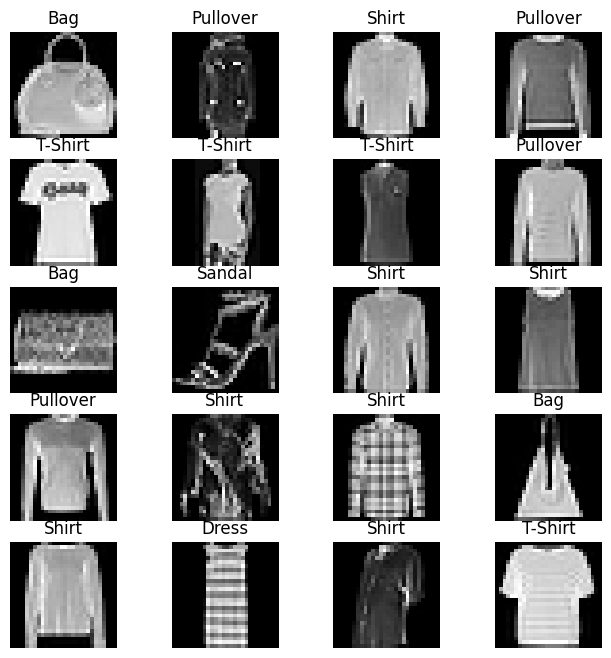

In [5]:
# 5-5 분류에 사용될 클래스 정의
labels_map = {0:'T-Shirt', 1:'Trouser', 2:'Pullover', 3:'Dress', 4:'Coat', 5:'Sandal',
              6:'Shirt', 7:'Sneaker', 8:'Bag', 9:'Ankle Boot'}

fig = plt.figure(figsize=(8,8))
columns = 4
rows = 5
for i in range(1, columns*rows +1):
  # 0~(train_dataset길이) 값을 갖는 분포에서 랜덤한 숫자 한 개 생성
  img_xy = np.random.randint(len(train_dataset))
  # 3차원 배열 생성
  img = train_dataset[img_xy][0][0,:,:]
  fig.add_subplot(rows, columns, i)
  plt.title(labels_map[train_dataset[img_xy][1]])
  plt.axis('off')
  plt.imshow(img, cmap='gray')
plt.show()

In [6]:
# 5-6 심층 신경망 모델 생성
class FashionDNN(nn.Module): # class형태의 모델은 항상 torch.nn.Module을 상속받음
  def __init__(self):
    super(FashionDNN, self).__init__()
    self.fc1 = nn.Linear(in_features=784, out_features=256)
    # p만큼의 비율로 텐서의 값이 0이 되고, 0이 되지 않은 값들은 기존 값에 (1/(1-p))만큼 곱해져 커짐
    self.drop = nn.Dropout(0.25)
    self.fc2 = nn.Linear(in_features=256, out_features=128)
    self.fc3 = nn.Linear(in_features=128, out_features=10)

  def forward(self, input_data): # 순전파 학습 진행
    out = input_data.view(-1,784) # input_data를 (?, 784)의 크기로 변경
    # 활성화 함수 지정
    out = F.relu(self.fc1(out)) # forward() 함수에서 정의 =/= nn.Relu : __init__() 함수에서 정의
    out = self.drop(out)
    out = F.relu(self.fc2(out))
    out = self.fc3(out)
    return out

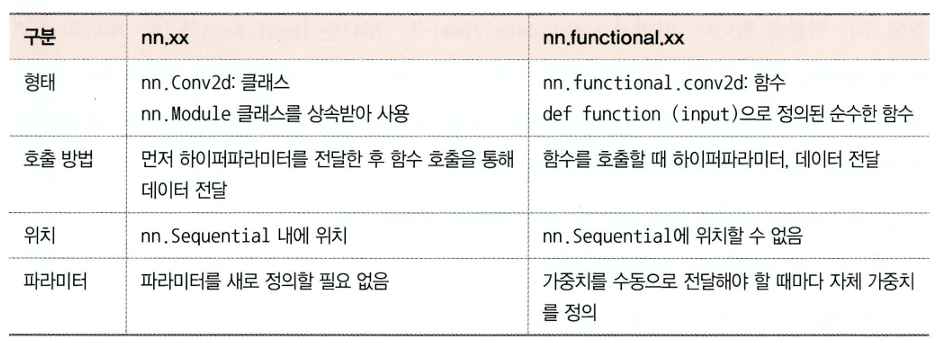

In [7]:
# 5-7 심층 신경망에서 필요한 파라미터 정의
learning_rate = 0.001
model = FashionDNN()
model.to(device)

criterion = nn.CrossEntropyLoss() # 분류 문제에서 사용하는 손실 함수
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [8]:
# 5-8 심층 신경망을 이용한 모델 학습
num_epochs = 5
count = 0

loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
  # 레코드(행, 가로줄)를 하나씩 가져옴 > 레코드에서 요소 두 개를 꺼내 오겠다는 의미
  for images, labels in train_loader:
    # 모델과 데이터가 동일한 장치에 있도록 함
    images, labels = images.to(device), labels.to(device)
    # 순전파 단계에서 모든 연산을 저장하고, 역전파 단계에서 저장된 값을 꺼내 사용
    # variable을 사용하여 역전파를 위한 미분 값을 자동으로 계산
    train = Variable(images.view(100,1,28,28))
    labels = Variable(labels)

    outputs = model(train)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count += 1

    if not (count % 50): # count를 50으로 나눴을 때 나머지가 0이 아니면 실행
      total = 0
      correct = 0
      for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        labels_list.append(labels)
        test = Variable(images.view(100,1,28,28))
        outputs = model(test)
        predictions = torch.max(outputs, 1)[1].to(device)
        predictions_list.append(predictions)
        correct += (predictions == labels).sum()
        total += len(labels)

      accuracy = correct * 100 / total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

    if not (count%500):
      print('Iteration: {}, Loss: {}, Accuracy: {}%'.format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.5820130109786987, Accuracy: 84.38500213623047%
Iteration: 1000, Loss: 0.5231814980506897, Accuracy: 85.71666717529297%
Iteration: 1500, Loss: 0.4018491804599762, Accuracy: 85.80999755859375%
Iteration: 2000, Loss: 0.36906254291534424, Accuracy: 87.2316665649414%
Iteration: 2500, Loss: 0.28320467472076416, Accuracy: 88.1050033569336%
Iteration: 3000, Loss: 0.2551303803920746, Accuracy: 88.63666534423828%


In [9]:
# 5-9 합성곱 네트워크 생성
class FashionCNN(nn.Module):
  def __init__(self):
    super(FashionCNN, self).__init__()
    self.layer1 = nn.Sequential(  # nn.Sequential은 계층을 차례로 쌓을 수 있도록 수식과 활성화 함수를 연결
        # 아래 채널 설명
        nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
        # 각 배치 단위별로 데이터가 다양한 분포를 가지더라도 평균과 분산을 이용해 정규화
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2) # 이미지 크기 축소
    )
    self.layer2 = nn.Sequential(
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.fc1 = nn.Linear(in_features=64*6*6, out_features=600)
    self.drop = nn.Dropout(0.25)
    self.fc2 = nn.Linear(in_features=600, out_features=120)
    self.fc3 = nn.Linear(in_features=120, out_features=10)

  def forward(self, x):
    out = self.layer1(x)
    out = self.layer2(out)
    out = out.view(out.size(0), -1) # (100,?)로 변환
    out = self.fc1(out)
    out = self.drop(out)
    out = self.fc2(out)
    out = self.fc3(out)
    return out

< 채널 >

- in_channels
  - 입력 채널의 수
  - 흑백 이미지는 1, RGB 값을 가진 이미지는 3을 가진 경우가 많음
  - = 깊이
- out_channel
  - 출력 채널의 수
- kernel_size
  - 커널의 크기 = 필터
  - 이미지 특징을 찾아내기 위한 공용 파라미터
  - 입력 데이터를 스트라이드 간격을 순회하며 합성곱 계산
  - ex. kernel_size = 3 : (3,3) 크기의 정사각형을 의미
- padding
  - 출력 크기 조정을 위해 입력 데이터 주위에 0을 채움
  - 패딩 값이 클수록 크기가 커짐

In [10]:
# 5-10 합성곱 네트워크를 위한 파라미터 정의
learning_rate = 0.001
model = FashionCNN()
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


In [11]:
# 5-11 모델 학습 및 성능 평가
num_epochs = 5
count = 0
loss_list=[]
iteration_list=[]
accuracy_list=[]

predictions_list=[]
labels_list=[]

for epoch in range(num_epochs):
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    train = Variable(images.view(100,1,28,28))
    labels = Variable(labels)

    outputs = model(train)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count += 1

    if not (count % 50):
      total = 0
      correct = 0
      for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        labels_list.append(labels)
        test = Variable(images.view(100,1,28,28))
        outputs = model(test)
        predictions = torch.max(outputs, 1)[1].to(device)
        predictions_list.append(predictions)
        correct += (predictions == labels).sum()
        total += len(labels)

      accuracy = correct * 100 / total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

    if not (count % 500):
      print('Iteration: {}, Loss: {}, Accuracy: {}%'.format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.5052564740180969, Accuracy: 88.663330078125%
Iteration: 1000, Loss: 0.35222724080085754, Accuracy: 89.89167022705078%
Iteration: 1500, Loss: 0.3567676842212677, Accuracy: 90.43333435058594%
Iteration: 2000, Loss: 0.21385246515274048, Accuracy: 91.77666473388672%
Iteration: 2500, Loss: 0.14946332573890686, Accuracy: 92.26333618164062%
Iteration: 3000, Loss: 0.21623025834560394, Accuracy: 92.08499908447266%
